# Continously stirred tank reactor

The functionality of the co-simulation is to be illustrated using the model of a stirred tank reactor, which is modeled as an ideally mixed system. This means that concentrated parameters are assumed for this system, so that the components in the container are completely mixed at all times and there are no concentration or temperature gradients in the spatial coordinates. In this case:

$$\frac{\partial }{\partial x}c=\frac{\partial }{\partial y}c=\frac{\partial }{\partial z}c=0$$

and 

$$\frac{\partial } {\partial x}T=\frac{\partial }{\partial y}T=\frac{\partial }{\partial z}T=0$$

In the case of a stirred tank reactor, we speak of discontinuous operation when at the beginning of operation a certain amount of reactants is added to the reactor and the products are removed again after a specified time and after the reaction has taken place (this is also referred to as a »batch process«). . In semi-continuous operation, some of the starting materials are metered in or part of the reaction mixture is removed during the reaction (this mode of operation is also referred to as a "semibatch process").
Such a reaction is typically found in the laboratory, when a reaction is carried out in a three-necked flask or Schlenk tube, or in an industrial environment, when smaller amounts in batches, e.g. B. be synthesized for the production of pharmaceuticals.
In contrast to discontinuous or semi-continuous operation, in continuous operation the educts are fed in continuously. Part of the reaction mixture is continuously removed to the same extent as new starting materials are fed in.
This type of reaction control is often used in an industrial context. The stirred tanks are then often operated in cascades in order to optimize sales.

<img src = "./model.svg" width=150px>


The example system used is to be operated continuously. This means that the supplied volume flow $q_{in}$ via $u_1$ corresponds to the discharged volume flow $q_{out}$ via $y_1$:

$${{q}_{in}}={{q}_{out}}={{q}_{r}}$$

The kinetics in the system under consideration should be dominated by a first-order reaction that does not cause any change in volume:

$$A\xrightarrow{{{r}_{A}}}\text{product}$$

The reaction rate $r_A$ per volume unit is modeled after the product approach. Here, $c_A$ represents the concentration of component $A$. The rate constant $k(T)$ depends on the temperature and is to be described using the Arrhenius approach:


$$r=k(T)\cdot{c_A}$$

with 

$$k(T) = k_0 e^{-\frac{E_a}{RT}}$$

where $E_a$ is the activation energy, $R$ is the general gas constant, and $T$ is the absolute temperature. $k_0$ represents the so-called pre-exponential factor (also known as "frequency factor"). The strong temperature dependence of this reaction becomes clear when the logarithm of the rate constant $k(T)$ is plotted against the reciprocal temperature over typical operating conditions. The following parameters are used as a basis for the example system under consideration:

\begin{align*}
E_a & = 72750\frac{J}{mol} \\
R & = 8.314\frac{J}{mol}\cdot K \\
k_0 & = 7.2\cdot {10}^{10}\frac{1}{min}
\end{align*}

The Arrhenius plot of the rate constants is shown by the following code block.

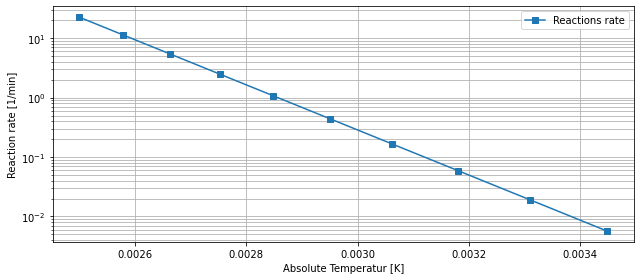

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Arrehnius parameters
Ea = 72750  # activation energy J/mol
R = 8.314   # gas constant J/mol/K
k0 = 7.2e10 # Arrhenius rate constant 1/min

# Arrhenius rate expression
def k(T):
    return k0*np.exp(-Ea/(R*T))

# Semilog plot of the rate constant
T = np.linspace(290,400,10)

plt.figure(figsize=(9, 4)) 
plt.semilogy(1/T, k(T), "C0-s", label="Reactions rate")
plt.xlabel("Absolute Temperatur [K]")
plt.legend()
plt.ylabel("Reaction rate [1/min]")
plt.grid(True, which="both")
plt.tight_layout()

## Model equations

The reaction rate shows a change of three orders of magnitude over the range of possible operating temperatures for the example system. Since an exothermic reaction releases heat faster at higher temperatures, a strong positive feedback is created that can potentially lead to an unstable process behaviour. This scenario is an example of the nonlinear dynamics of an exothermic, ideally mixed, stirred tank reactor. It has been studied by many researchers and students since it was pioneered by Amundson and Aris in the 1950s. The specific formulations and parameter values described below are taken from Example 2.5 by Seborg et al [Seborg DE, Edgar TF, Mellichamp DA, Doyle FJ (2017) Process dynamics and control. Wiley, Hoboken, NJ].

The reactor is to be cooled by a jacket. Here, too, the supplied volume flow of the cooling medium $u_2$ corresponds to the discharged volume flow via $y_2$. The interactions between gas and liquid phase should be neglected. In addition to the constancy of the material properties, it is also assumed that the product temperature at the outlet corresponds to the reactor temperature. The conservation equations for mass and energy lead to the following differential equations for a constant reaction volume with the assumptions described:


\begin{align*}
V_r\frac{dc_A}{dt} & = q_r(c_{A,f}-c_A)-V_r k(T_r) c_A \\
V_r \rho_r C_{p,r}\frac{dT}{dt} & = q_r \rho_r C_{p,r} (T_{r,f}-T_r) + (-\Delta H_R)V_r k(T_r)c_A + UA(T_c-T_r) \\
\end{align*}

Here the state variables of the system are $c_A$ the oncentration of component $A$, $T_r$ the reactor temperature and $T_c$ the temeprature inside the cooling jacket. For $k(T)$ the Arrhenius-equation is applied:

$$k(T) = k_0 e^{-\frac{E_a}{RT}}$$

The temperature inside the cooling jacket is determined by the cooling medium flow $q_c$ and the correspondig energy balance:

\begin{align*}
V_c \rho_c C_{p,c}\frac{dT_c}{dt} & = q_c \rho_c C_{p,c} (T_{c,f}-T_c) + UA(T_r - T_c)
\end{align*}

The normalization of the equations lead to changing rates of $c_A$, $T_r$, und $T_c$.

\begin{align*}
\frac{dc_A}{dt} & = \frac{q_r}{V_r}(c_{A,f} - c_A)- k(T_r)c_A \\
\frac{dT_r}{dt} & = \frac{q_r}{V_r}(T_{r,f} - T_r) + \frac{-\Delta H_R}{\rho_r C_{p,r}}k(T_r)c_A + \frac{UA}{V_r \rho_r C_{p,r}}(T_c - T_r) \\
\frac{dT_c}{dt} & = \frac{q_c}{V_c}(T_{c,f}-T_c) + \frac{UA}{V_c \rho_c C_{p,c}}(T_r - T_c)
\end{align*}

## Parameters

The equations will be integrated with the follwing parameters.

| Parameter | Symbol | Value | Unit | 
| :------- | :----: | :---: | :---- |
| Activation energy | $E_a$ | 72750 | J/mol |
| General gas constant | $R$ | 8.314 | J/mol/K |
| Arrhenius frequency factor | $k_0$ | 1.2 x 10<sup>9</sup> | 1/s |
| Reactionsenthalpy | $\Delta H_R$ | -50000  | J/mol |
| Volume of the reactor | $V_r$ | 0.1 | m<sup>3</sup> |
| Density in the reactor | $\rho_r$ | 1000 | kg/m<sup>3</sup> |
| Heat capacity in the reactor  | $C_{p,r}$ | 239.0 | J/kg/K |
| Feed flow rate | $q_{r,f}$ | 100 | l/min |
| Feed temperature | $T_{r,f}$ | 300 | K |
| Feed concentration | $c_{A,f}$ | 1000 | mol/m<sup>3</sup> |
| Initial temperature in the reactor | $T_{r,0}$ | 350 | K |
| Initial concentration in the reactor | $c_{A,0}$ | 500 | mol/m<sup>3</sup> |
| Volume of the cooling jacket | $V_c$ | 0.2 | m<sup>3</sup> | 
| Densitiy of the cooling medium | $\rho_c$ | 1000 | kg/m<sup>3</sup> |
| Heat capacity of the cooling medium | $C_{p,c}$ | 239.0 | J/kg/K |
| Cooling medium flow rate | $q_{c,f}$ | 153 | l/min | 
| Temperature of the cooling medium | $T_{c,f}$ | 300 | K |
| Heat transfer coefficient | $UA$ | 833.3 | J/s/K |

## Implementation of the model

In [4]:
from simunetcore import Model
import numpy as np
import math
from scipy.integrate import odeint  

# Model implementation for the reactor
class CSTR(Model):
    def __init__(self, name:str=""):
        Model.__init__(self, name)
        # Model parameters
        self.params = {
            # Parameters Reaction rate
            "E_a"   : {"value": 72750.0, "description": "Activation energy", "unit": "J/mol"},
            "R"     : {"value": 8.314, "description": "Gas constant", "unit": "J/mol/K"},
            "k_0"   : {"value": 1.2e9, "description": "Arrhenius rate constant", "unit": "1/s"},
            "dH_R"  : {"value": -5.0e4, "description": "Enthalpy of reaction", "unit": "J/mol"},
            # Parameters Reactor
            "V_r"   : {"value": 0.1, "description": "Volume", "unit": "m^3"},
            "rho_r" : {"value": 1000.0, "description": "Density", "unit": "kg/m^3"},
            "C_p_r" : {"value": 239.0, "description": "Heat capacity", "unit": "J/kg/K"},
            # Parameters Cooling jacket
            "V_c"   : {"value": 0.020, "description": "Cooling jacket volume", "unit": "m^3"},
            "rho_c" : {"value": 1000.0, "description": "Density", "unit": "kg/m^3"},
            "C_p_c" : {"value": 239.0, "description": "Heat capacity", "unit": "J/kg/K"},
            "UA"    : {"value": 833.3, "description": "Heat transfer", "unit": "J/s/K"},
            # ODE solver parameter
            "abserr": {"value": 1.0e-8, "description": "Absolute tolerance", "unit": "-"},
            "relerr": {"value": 1.0e-6, "description": "Relative tolerance", "unit": "-"}
        }
        # Model variables
        self.vars = {
            "c_A_f" : {"description": "Feed concentration", "unit": "mol/m^3"}, 
            "q_r_f" : {"description": "Reactor feed flow rate", "unit": "m^3/s"},
            "T_r_f" : {"description": "Reactor feed temperature", "unit": "K"},
            "c_A"   : {"description": "Reactor concentration", "unit": "mol/m^3"}, 
            "T_r"   : {"description": "Reactor temperature", "unit": "K"},
            "q_c_f" : {"description": "Cooling feed flow rate", "unit": "m^3/s"},
            "T_c_f" : {"description": "Cooling feed temperature", "unit": "K"},
            "T_c"   : {"description": "Cooling outlet temperature", "unit": "K"}
        }
        # Model inputs
        self.u = {
            "u_1"   : {"type": "liquid", "description": "Reactor feed input", "vars": ["c_A_f", "q_r_f", "T_r_f"]},
            "u_2"   : {"type": "liquid", "description": "Cooling jacket feed input", "vars": ["q_c_f", "T_c_f"]}
        }
        # Model outputs
        self.y = {
            "y_1"   : {"type": "liquid", "description": "Reactor output", "vars": ["c_A", "T_r"]},
            "y_2"   : {"type": "liquid", "description": "Cooling jacket output", "vars": ["T_c"]},
            "y_3"   : {"type": "measure", "description": "Reactor temperatur",  "vars": ["T_r"]}
        }
        # Port adjacencies
        self.adj = [
            ["u_2", "y_2"]
        ]
        
    def compute(self, *args, **kwargs):
        # ODE solver parameter
        abserr = self.get_param("abserr") # Absolute tolerance
        relerr = self.get_param("relerr") # Relative tolerance
        t_frame = self.get_t()
        
        # Create initial vector
        y_0 = [self.get_var("c_A")[-1], self.get_var("T_r")[-1], self.get_var("T_c")[-1]]
        y_sol = odeint(self.odeint_callback, y_0, t_frame, atol=abserr, rtol=relerr)
        
        # Store results
        self.set_var("c_A", y_sol[:,0])
        self.set_var("T_r", y_sol[:,1])
        self.set_var("T_c", y_sol[:,2])

    def odeint_callback(self, y, t):
        # Parameters reaction rate
        E_a    = self.get_param("E_a")   # Activation energy [J/mol]
        R      = self.get_param("R")     # Gas constant [J/mol/K]
        k_0    = self.get_param("k_0")   # Arrhenius rate constant, [1/s]
        dH_R   = self.get_param("dH_R")  # Enthalpy of reaction [J/mol]
        # Parameters reactor
        V_r    = self.get_param("V_r")   # Volume [m³]
        rho_r  = self.get_param("rho_r") # Density [kg/m³]
        C_p_r  = self.get_param("C_p_r") # Heat capacity [J/kg/K]
        # Parameters cooling jacket
        V_c    = self.get_param("V_c")   # Cooling jacket volume [m³]
        rho_c  = self.get_param("rho_c") # Density [kg/m³]
        C_p_c  = self.get_param("C_p_c") # Heat capacity [J/kg/K]
        UA     = self.get_param("UA")    # Heat transfer [J/s/K]    
        
        # State variables
        c_A, T_r, T_c = y
        
        # Coupling vector
        c_A_f = self.get_var("c_A_f", t)
        q_r_f = self.get_var("q_r_f", t)
        T_r_f = self.get_var("T_r_f", t)
        q_c_f = self.get_var("q_c_f", t)
        T_c_f = self.get_var("T_c_f", t)
        # Arrhenius rate expression
        k = lambda T : k_0 * np.exp(-E_a / R / T)

        # Differential equations
        d_c_A = (q_r_f/V_r)*(c_A_f-c_A)-k(T_r)*c_A
        d_T_r = (q_r_f/V_r)*(T_r_f-T_r)+(-dH_R/rho_r/C_p_r)*k(T_r)*c_A+\
                (UA/V_r/rho_r/C_p_r)*(T_c-T_r)
        d_T_c = (q_c_f/V_c)*(T_c_f-T_c)+\
                (UA/V_c/rho_c/C_p_c)*(T_r-T_c)

        dy = [d_c_A, d_T_r, d_T_c]
        return dy 

## Computation of the model

In [5]:
# Create model
M_1 = CSTR("M_1")

# Setup integration time
t_start = 0.0
t_end = 300.0
numpoints = 1001
M_1.set_t(np.linspace(t_start, t_end, numpoints))

# Setup inital values
M_1.set_var("c_A", [500.0]) # Initial concentration [mol/m³]
M_1.set_var("T_r", [350.0]) # Initial temperature [K]
M_1.set_var("T_c", [300.0]) # Initialcooling jacket temperature [K]

# Setup input vector
c_A_f = np.full(numpoints, 1000.0)
q_r_f = np.full(numpoints, 100.0/1000.0/60.0) # Convert 100l/min to m³/s
T_r_f = np.full(numpoints, 300.0)
q_c_f = np.full(numpoints, 153.0/1000.0/60.0) # Convert 100l/min to m³/s
T_c_f = np.full(numpoints, 300.0)
u_1 = [c_A_f, q_r_f, T_r_f]
u_2 = [q_c_f, T_c_f]

# Assign input vectors
M_1.set_u("u_1", u_1)
M_1.set_u("u_2", u_2)

# Solve model
M_1.compute()

## Results

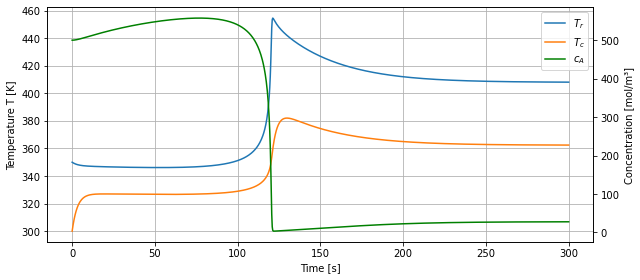

In [6]:
import matplotlib
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(9,4))

# Plot temperatures
line1=plt.plot(M_1.get_t(), M_1.get_var("T_r"), label="$T_r$")
line2=plt.plot(M_1.get_t(), M_1.get_var("T_c"), label="$T_c$")

# Axis labels
plt.ylabel("Temperature T [K]")
plt.xlabel("Time [s]")

# Show grid
plt.grid(True)

# Twin x Axis
plt.twinx()

# Plot concentrations
line3=plt.plot(M_1.get_t(), M_1.get_var("c_A"), "g", label="$c_A$")

# Axis label
plt.ylabel("Concentration [mol/m³]")

# Show legend
lines = line1+line2+line3
labels = [line.get_label() for line in lines]
plt.legend(lines, labels, loc=1)

# Layout and show
plt.tight_layout()
plt.show()